Доступные символы: ['(', ')', '+', '-', ',', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'x', 'y', 't']


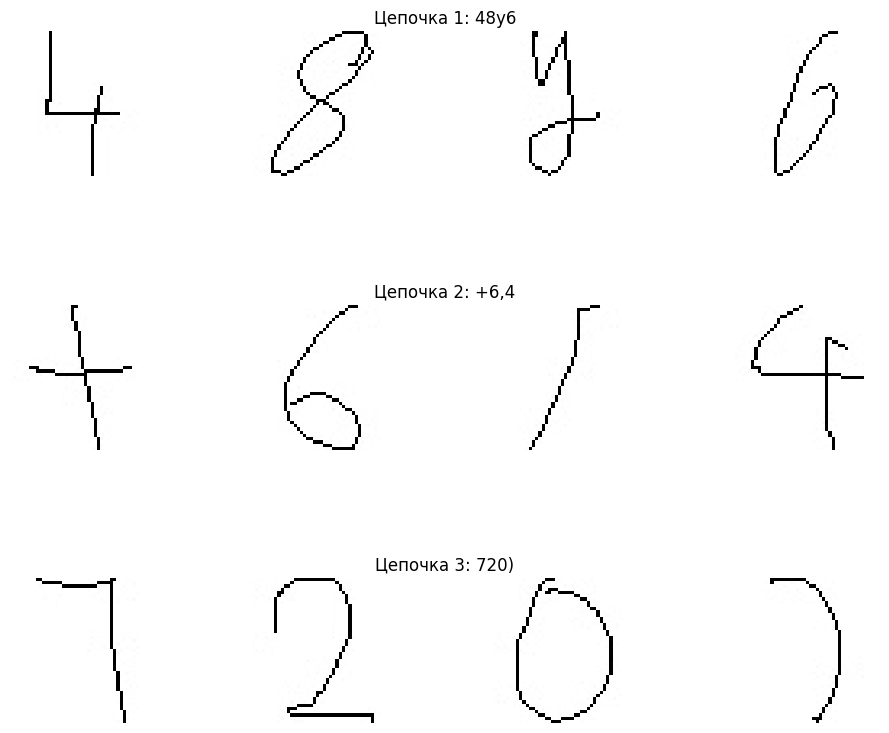


 Обработка цепочки 1: '48y6' 


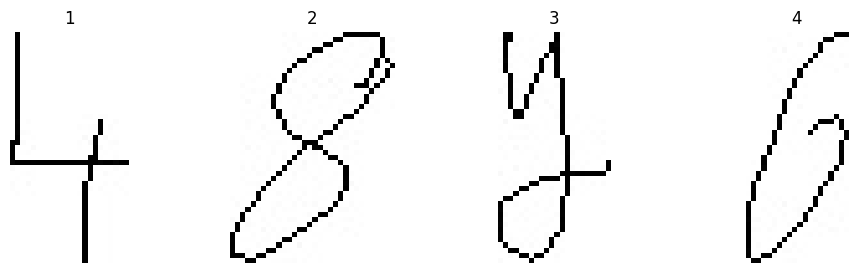


 Обработка цепочки 2: '+6,4' 


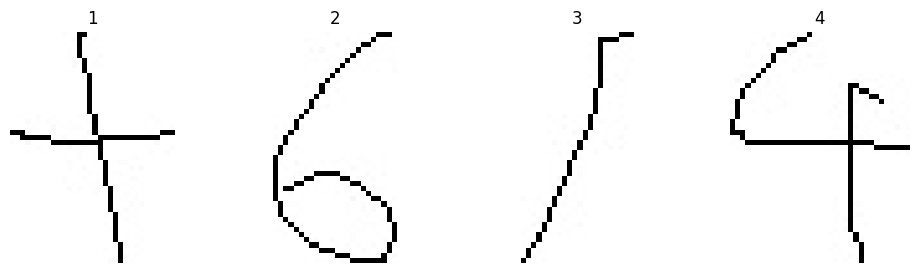


 Обработка цепочки 3: '720)' 


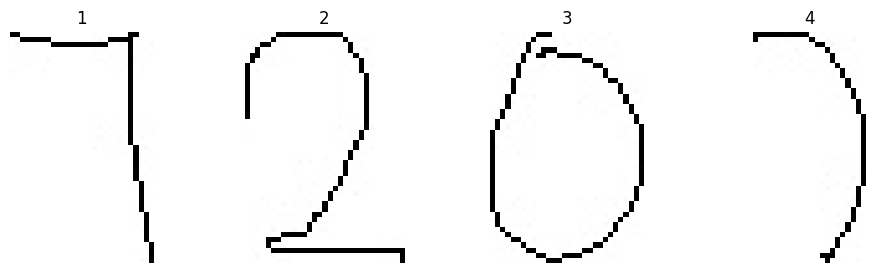

Загружено обучающих изображений: 180225
KNN (k=1) обучен
KNN (k=3) обучен
KNN (k=5) обучен

Первая классификация: 4


In [1]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

def normalize_symbol(img, out_size=45):
    _, th = cv2.threshold(img, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    coords = cv2.findNonZero(th)

    if coords is None:
        return np.full((out_size, out_size), 255, dtype=np.uint8)

    x, y, w, h = cv2.boundingRect(coords)

    if w == 0 or h == 0:
        return np.full((out_size, out_size), 255, dtype=np.uint8)

    symbol = th[y:y+h, x:x+w]

    scale = min(out_size / w, out_size / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    resized = cv2.resize(symbol, (new_w, new_h), interpolation=cv2.INTER_AREA)

    result = np.full((out_size, out_size), 255, dtype=np.uint8)
    x0 = (out_size - new_w) // 2
    y0 = (out_size - new_h) // 2
    result[y0:y0+new_h, x0:x0+new_w] = resized

    return result

class SymbolImageGenerator:
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.char_map = {
            '(': '(', ')': ')', '+': '+', '-': '-', ',': ',', '*': 'times',
            '0': '0', '1': '1', '2': '2',
            '3': '3', '4': '4', '5': '5',
            '6': '6', '7': '7', '8': '8', '9': '9',
            'x': 'X', 'y': 'y', 't': 't'
        }
        self.available_chars = list(self.char_map.keys())
        print(f"Доступные символы: {self.available_chars}")

    def get_random_image(self, ch):
        folder = os.path.join(self.data_dir, self.char_map[ch])
        files = sorted(os.listdir(folder))
        files = [f for f in files if os.path.isfile(os.path.join(folder, f))]

        val_split = int(len(files) * 0.8)
        candidates = files[val_split:]

        img_file = random.choice(candidates)
        return cv2.imread(os.path.join(folder, img_file), cv2.IMREAD_GRAYSCALE)

    def generate_chain(self, length=4):
        chain = ''.join(random.choices(self.available_chars, k=length))
        imgs = [self.get_random_image(ch) for ch in chain]
        return chain, imgs


def merge_images(images, spacing=25):
    total_w = sum(img.shape[1] for img in images) + spacing * (len(images) - 1)
    max_h = max(img.shape[0] for img in images)
    canvas = np.full((max_h, total_w), 255, dtype=np.uint8)

    x = 0
    for img in images:
        h, w = img.shape
        y = max_h - h
        canvas[y:y+h, x:x+w] = img
        x += w + spacing
    return canvas

generator = SymbolImageGenerator(r'C:\Users\User\Documents\data_laba_9_IM')

chains = []
chain_images = []

for i in range(3):
    text, imgs = generator.generate_chain(length=4)
    chains.append(text)
    chain_images.append(imgs)

merged = [merge_images(imgs, spacing=30) for imgs in chain_images]

plt.figure(figsize=(9, 9))
for idx, (img, txt) in enumerate(zip(merged, chains)):
    plt.subplot(3, 1, idx+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Цепочка {idx+1}: {txt}")
    plt.axis('off')
plt.tight_layout()
plt.show()

processed_sequences = []

for idx, (img, text) in enumerate(zip(merged, chains)):
    print(f"\n Обработка цепочки {idx+1}: '{text}' ")

    _, binary = cv2.threshold(img, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = 255 - binary 

    contours, _ = cv2.findContours(binary,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

    chars = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w * h > 50:
            ch_img = img[y:y+h, x:x+w]
            chars.append((x, ch_img))

    fig, axarr = plt.subplots(1, len(chars), figsize=(12, 3))
    if len(chars) == 1:
        axarr = [axarr]
    for i, (_, ch_img) in enumerate(chars):
        axarr[i].imshow(ch_img, cmap='gray')
        axarr[i].set_title(f'{i+1}')
        axarr[i].axis('off')
    plt.show()

    processed_sequences.append({
        'text': text,
        'symbols': chars
    })

def load_training_data(base_path, chars, split_ratio=0.8):
    X, y = [], []

    for ch in chars:
        folder_name = ch if ch != '*' else 'times'
        label = ch

        folder = os.path.join(base_path, folder_name)
        files = sorted(os.listdir(folder))
        files = [f for f in files if os.path.isfile(os.path.join(folder, f))]

        random.shuffle(files)

        cutoff = int(len(files) * split_ratio)
        train_files = files[:cutoff]

        for f in train_files:
            img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
            img_norm = normalize_symbol(img)
            X.append(img_norm.flatten())
            y.append(label)

    return np.array(X), np.array(y)


symbols = ['0','1','2','3','4','5','6','7','8','9',
           '+','-','t','X','y','w','h','(',')',',','*']

X_train, y_train = load_training_data(r'C:\Users\User\Documents\data_laba_9_IM', symbols)
print(f"Загружено обучающих изображений: {len(X_train)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

knn_models = {}
for k in [1, 3, 5]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_scaled, y_train)
    knn_models[k] = model
    print(f"KNN (k={k}) обучен")

def predict_symbol(model, img):
    img_norm = normalize_symbol(img)
    flat = img_norm.flatten()

    flat_scaled = scaler.transform([flat])
    return model.predict(flat_scaled)[0]

example_img = processed_sequences[0]['symbols'][0][1]
print("\nПервая классификация:", predict_symbol(knn_models[3], example_img))

In [2]:
print("   ОЦЕНКА РАБОТЫ МОДЕЛЕЙ KNN  ")

for k, model in knn_models.items():
    print(f" Модель KNN(k={k}) ")

    correct = 0
    total = 0

    for seq in processed_sequences:
        true_text = seq['text']
        pred = ''.join(predict_symbol(model, ch_img)
                       for _, ch_img in seq['symbols'])

        ok = (pred == true_text)
        if ok: correct += 1
        total += 1

        print(f"Цепочка: истинная = {true_text}   распознано = {pred}   {'✓' if ok else '✗'}")

    print(f"Точность модели k={k}: {correct/total:.2f}\n")

   ОЦЕНКА РАБОТЫ МОДЕЛЕЙ KNN  
 Модель KNN(k=1) 
Цепочка: истинная = 48y6   распознано = 48y6   ✓
Цепочка: истинная = +6,4   распознано = +6,4   ✓
Цепочка: истинная = 720)   распознано = 720)   ✓
Точность модели k=1: 1.00

 Модель KNN(k=3) 
Цепочка: истинная = 48y6   распознано = 48y6   ✓
Цепочка: истинная = +6,4   распознано = +6,4   ✓
Цепочка: истинная = 720)   распознано = 720)   ✓
Точность модели k=3: 1.00

 Модель KNN(k=5) 
Цепочка: истинная = 48y6   распознано = 48y6   ✓
Цепочка: истинная = +6,4   распознано = +6,4   ✓
Цепочка: истинная = 720)   распознано = 720)   ✓
Точность модели k=5: 1.00

